In [1]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd
import nltk
from nltk.corpus import stopwords
import string


In [2]:
# nltk.download('punkt_tab')

In [5]:
# Convert to DataFrame
df = pd.read_csv('data/agent_conversations.csv', encoding='latin1')

[nltk_data] Downloading package stopwords to /Users/beto/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


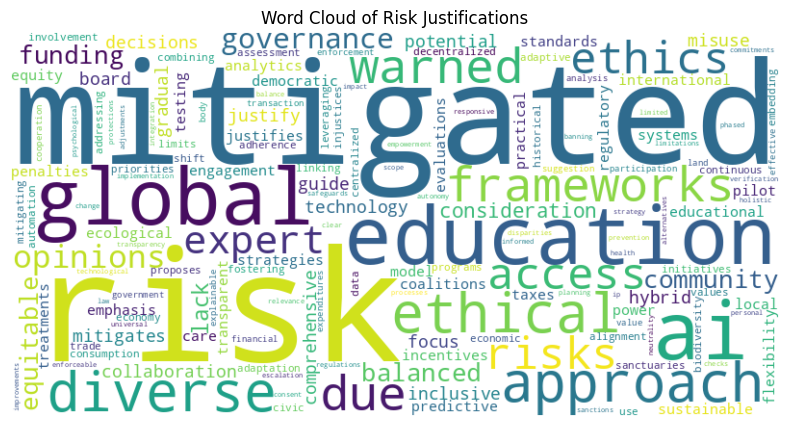

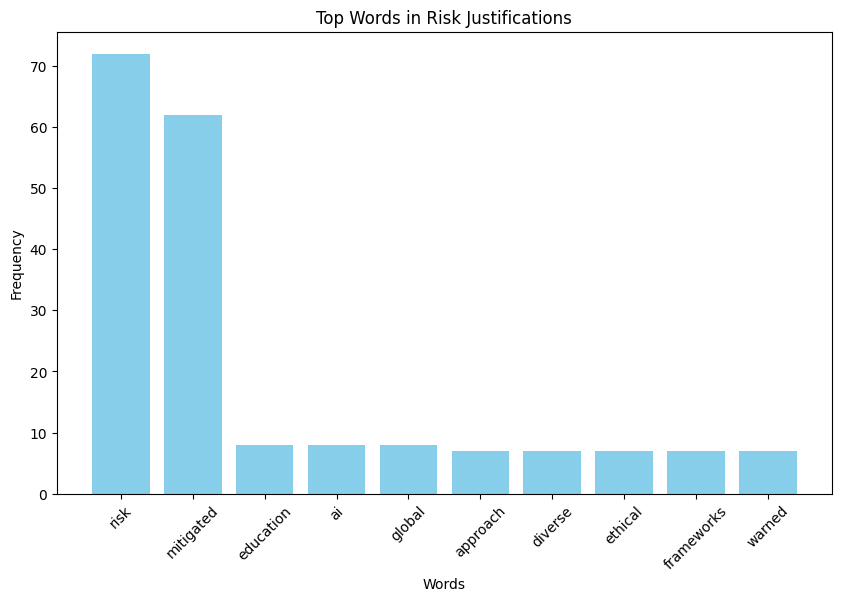

In [6]:
# Preprocess text
nltk.download("stopwords")
stop_words = set(stopwords.words("english")) | set(string.punctuation)

def preprocess(text):
    return [
        word.lower()
        for word in nltk.word_tokenize(text)
        if word.lower() not in stop_words and word.isalpha()
    ]

# Tokenize and preprocess
df["Processed"] = df["Risk Justification"].apply(preprocess)

# Flatten the list of words and count occurrences
all_words = [word for tokens in df["Processed"] for word in tokens]
word_counts = Counter(all_words)

# Word Cloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(word_counts)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Risk Justifications")
plt.show()

# Bar Chart
top_words = word_counts.most_common(10)
words, counts = zip(*top_words)

plt.figure(figsize=(10, 6))
plt.bar(words, counts, color="skyblue")
plt.title("Top Words in Risk Justifications")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()


Topic 1: approach, ai, global, mitigated, risk
Topic 2: governance, expert, opinions, mitigated, risk
Topic 3: warned, ethical, education, mitigated, risk


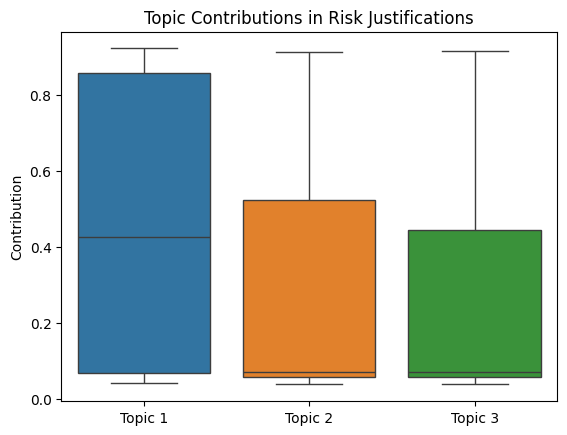

In [7]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Vectorize the text
vectorizer = CountVectorizer(stop_words="english")
X = vectorizer.fit_transform(df["Risk Justification"])

# Fit LDA
lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(X)

# Get topic contributions
topics = lda.components_
words = vectorizer.get_feature_names_out()

# Top words per topic
for idx, topic in enumerate(topics):
    print(f"Topic {idx + 1}: {', '.join([words[i] for i in topic.argsort()[-5:]])}")

# Visualize topic contributions
import seaborn as sns
import numpy as np

topic_contributions = lda.transform(X)
df_topics = pd.DataFrame(topic_contributions, columns=[f"Topic {i+1}" for i in range(topic_contributions.shape[1])])

sns.boxplot(data=df_topics)
plt.title("Topic Contributions in Risk Justifications")
plt.ylabel("Contribution")
plt.show()


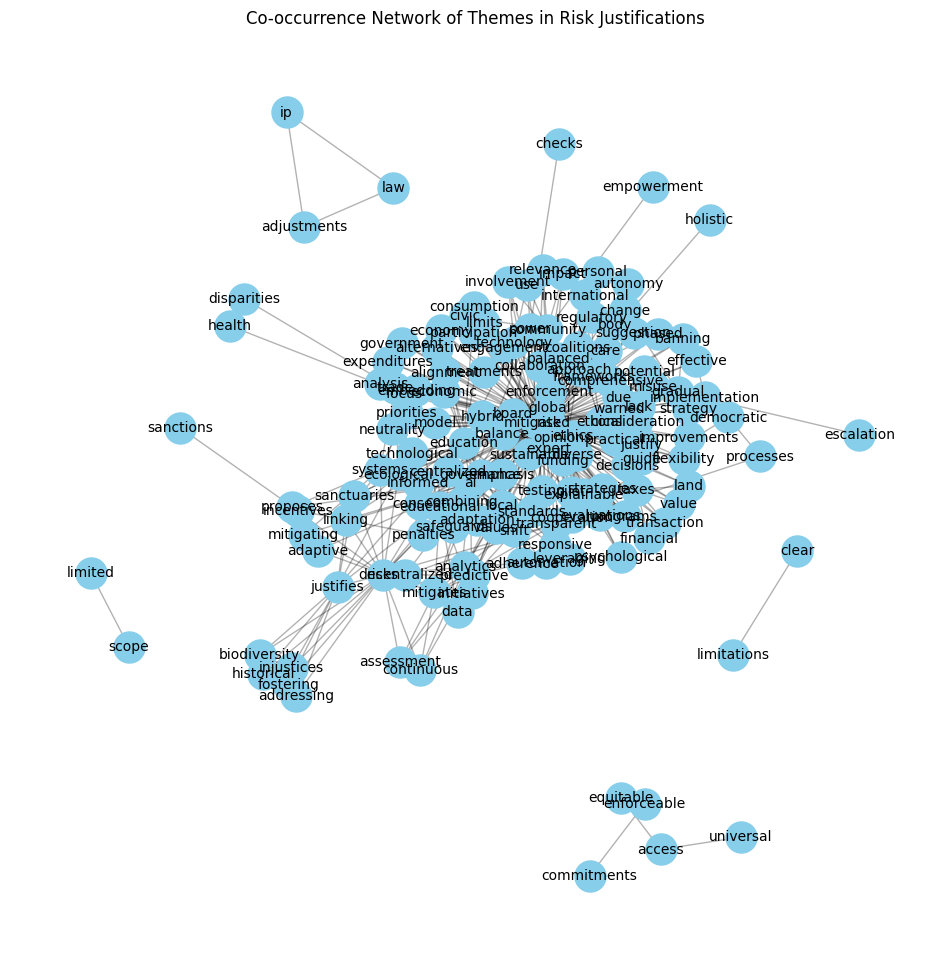

In [8]:
import networkx as nx

# Create co-occurrence matrix
co_occurrence = pd.DataFrame(0, index=word_counts.keys(), columns=word_counts.keys())
for tokens in df["Processed"]:
    for i in range(len(tokens)):
        for j in range(i + 1, len(tokens)):
            co_occurrence.loc[tokens[i], tokens[j]] += 1
            co_occurrence.loc[tokens[j], tokens[i]] += 1

# Create a graph
G = nx.Graph()
for word1, row in co_occurrence.iterrows():
    for word2, value in row.items():
        if value > 0:
            G.add_edge(word1, word2, weight=value)

# Draw the network
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, k=0.3)
nx.draw_networkx_nodes(G, pos, node_size=500, node_color="skyblue")
nx.draw_networkx_edges(G, pos, alpha=0.3)
nx.draw_networkx_labels(G, pos, font_size=10)
plt.title("Co-occurrence Network of Themes in Risk Justifications")
plt.axis("off")
plt.show()


/Users/beto/Documents/Projects/AIAlignment/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use mps:0


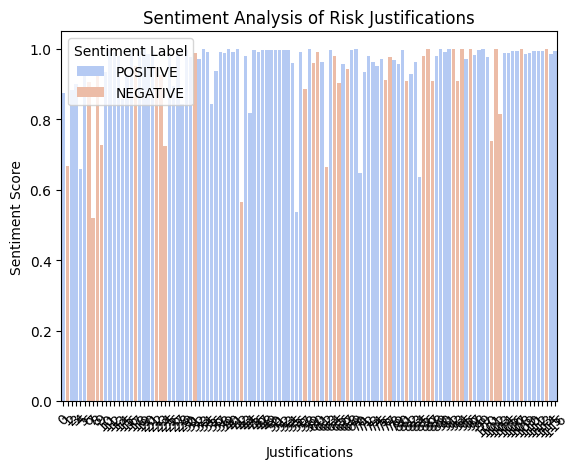

In [9]:
from transformers import pipeline

# Sentiment Analysis Pipeline
sentiment_analyzer = pipeline("sentiment-analysis")
df["Sentiment"] = df["Risk Justification"].apply(lambda x: sentiment_analyzer(x)[0])

# Extract Sentiment Scores
df["Sentiment Score"] = df["Sentiment"].apply(lambda x: x["score"])
df["Sentiment Label"] = df["Sentiment"].apply(lambda x: x["label"])

# Plot Sentiment Scores
sns.barplot(x=df.index, y="Sentiment Score", hue="Sentiment Label", data=df, palette="coolwarm")
plt.title("Sentiment Analysis of Risk Justifications")
plt.xlabel("Justifications")
plt.ylabel("Sentiment Score")
plt.xticks(rotation=45)
plt.show()


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


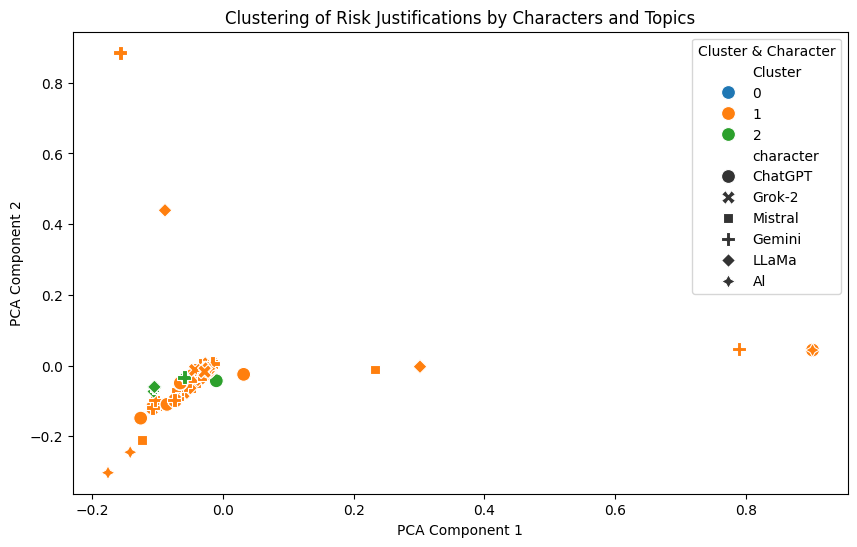

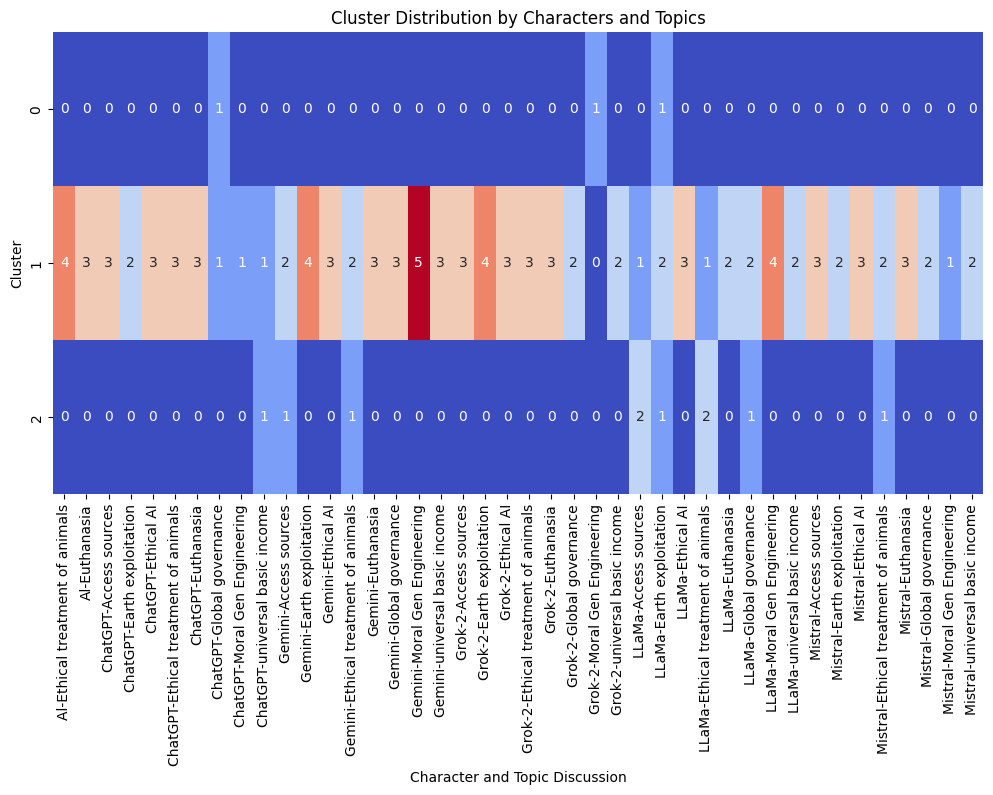

In [10]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: TF-IDF Vectorization
tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(df["Risk Justification"])

# Step 2: Apply K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(tfidf_matrix)

# Step 3: Dimensionality Reduction for Visualization
pca = PCA(n_components=2, random_state=42)
reduced_dims = pca.fit_transform(tfidf_matrix.toarray())
df["PCA1"] = reduced_dims[:, 0]
df["PCA2"] = reduced_dims[:, 1]

# Step 4: Scatterplot with Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="PCA1", y="PCA2", hue="Cluster", style="character", data=df, palette="tab10", s=100
)
plt.title("Clustering of Risk Justifications by Characters and Topics")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster & Character")
plt.show()

# Step 5: Heatmap of Cluster Distribution
heatmap_data = pd.crosstab(df["Cluster"], [df["character"], df["topic_discussion"]])

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="coolwarm", cbar=False)
plt.title("Cluster Distribution by Characters and Topics")
plt.ylabel("Cluster")
plt.xlabel("Character and Topic Discussion")
plt.show()


Cluster 1:
Top terms and their importance:
  - risk: 0.1423
  - mitigated: 0.1410
  - education: 0.0391
  - access: 0.0377
  - expert: 0.0349
  - opinions: 0.0349
  - ethical: 0.0349
  - diverse: 0.0348
  - global: 0.0337
  - equitable: 0.0334


Cluster 2:
Top terms and their importance:
  - approach: 0.4189
  - balanced: 0.3524
  - mitigated: 0.1801
  - hybrid: 0.1655
  - risk: 0.1654
  - model: 0.1217
  - holistic: 0.0785
  - phased: 0.0785
  - frameworks: 0.0654
  - sustainable: 0.0547


Cluster 0:
Top terms and their importance:
  - democratic: 0.4368
  - transparent: 0.3416
  - frameworks: 0.1999
  - processes: 0.1997
  - decentralized: 0.1716
  - mitigates: 0.1482
  - governance: 0.1345
  - risks: 0.1293
  - mitigated: 0.1071
  - risk: 0.0984




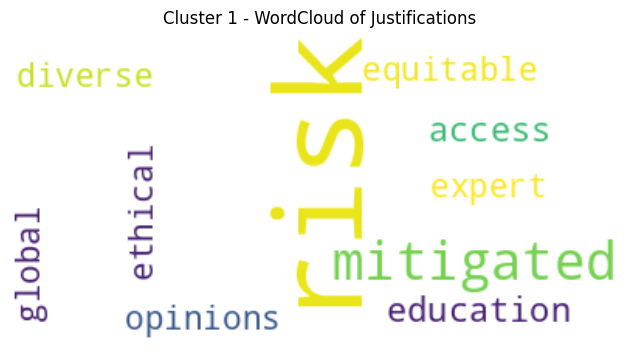

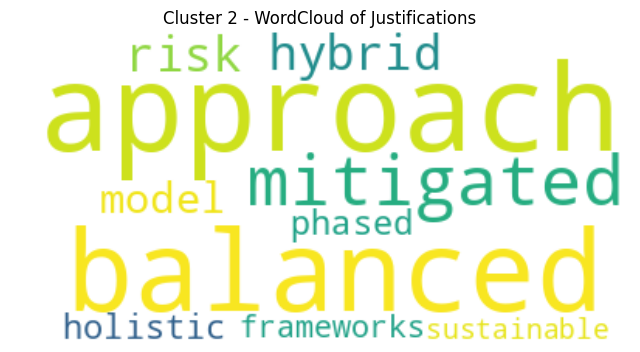

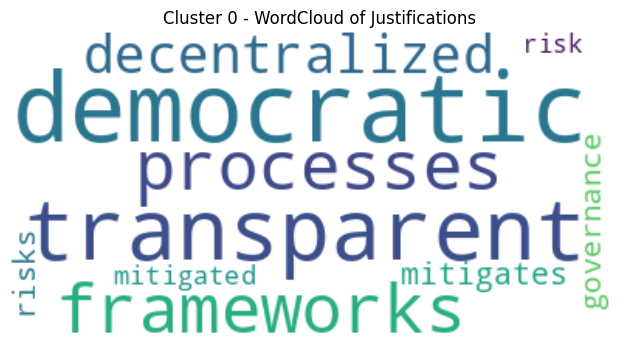

In [11]:
from sklearn.feature_extraction.text import TfidfTransformer
import numpy as np
from wordcloud import WordCloud

# Step 1: Get the cluster labels
clusters = df["Cluster"].unique()

# Step 2: Extract the top terms per cluster
terms = tfidf.get_feature_names_out()
cluster_terms = {}

for cluster in clusters:
    # Get indices of justifications in the cluster
    cluster_indices = df[df["Cluster"] == cluster].index
    cluster_matrix = tfidf_matrix[cluster_indices]
    
    # Calculate average TF-IDF scores for terms in the cluster
    mean_tfidf = np.array(cluster_matrix.mean(axis=0)).flatten()
    sorted_indices = mean_tfidf.argsort()[::-1]  # Sort in descending order
    top_terms = [(terms[i], mean_tfidf[i]) for i in sorted_indices[:10]]  # Top 10 terms
    
    cluster_terms[cluster] = top_terms

# Step 3: Generate explanations
for cluster, terms_scores in cluster_terms.items():
    print(f"Cluster {cluster}:")
    print("Top terms and their importance:")
    for term, score in terms_scores:
        print(f"  - {term}: {score:.4f}")
    print("\n")

# Step 4: Visualize terms using Word Clouds
for cluster, terms_scores in cluster_terms.items():
    # Create a dictionary for the WordCloud
    word_dict = {term: score for term, score in terms_scores}
    
    # Generate WordCloud
    wordcloud = WordCloud(background_color="white", colormap="viridis").generate_from_frequencies(word_dict)
    
    # Plot WordCloud
    plt.figure(figsize=(8, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Cluster {cluster} - WordCloud of Justifications")
    plt.show()


In [12]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
from transformers import pipeline

# Vectorize the justifications
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
dtm = vectorizer.fit_transform(df['Risk Justification'])

# Topic Modeling
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(dtm)

# Extract topics
terms = vectorizer.get_feature_names_out()
topics = {}
for idx, topic in enumerate(lda.components_):
    topics[f"Topic {idx}"] = [terms[i] for i in topic.argsort()[-10:]]

# Print topics
for topic, words in topics.items():
    print(f"{topic}: {', '.join(words)}")

# Sentiment Analysis
sentiment_analyzer = pipeline('sentiment-analysis')
df['Sentiment'] = df['Risk Justification'].apply(lambda x: sentiment_analyzer(x)[0]['label'])


No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use mps:0


Topic 0: decision, lack, consideration, balanced, approach, ethical, warned, education, mitigated, risk
Topic 1: regulatory, ecological, collaboration, ai, mitigates, global, risks, risk, frameworks, mitigated
Topic 2: decisions, justify, expert, opinions, equitable, funding, access, diverse, mitigated, risk
Topic 3: engagement, model, hybrid, board, ethics, global, community, ai, risk, mitigated
Topic 4: ethical, frameworks, transparent, coalitions, democratic, international, expert, opinions, risk, mitigated


In [13]:
character_profiles = df.groupby('character').agg({
    'Sentiment': lambda x: x.value_counts(normalize=True).to_dict(),
    'Risk Justification': ' '.join
}).reset_index()

# Add dominant topic per character
for char in character_profiles['character']:
    char_justifications = character_profiles.loc[character_profiles['character'] == char, 'Risk Justification'].values[0]
    char_vector = vectorizer.transform([char_justifications])
    topic_dist = lda.transform(char_vector)
    dominant_topic = topic_dist.argmax()
    character_profiles.loc[character_profiles['character'] == char, 'Dominant Topic'] = f"Topic {dominant_topic}"

print(character_profiles)


  character                                          Sentiment  \
0        Al  {'NEGATIVE': 0.5714285714285714, 'POSITIVE': 0...   
1   ChatGPT  {'POSITIVE': 0.6842105263157895, 'NEGATIVE': 0...   
2    Gemini  {'POSITIVE': 0.7777777777777778, 'NEGATIVE': 0...   
3    Grok-2  {'POSITIVE': 0.6190476190476191, 'NEGATIVE': 0...   
4     LLaMa  {'POSITIVE': 0.8333333333333334, 'NEGATIVE': 0...   
5   Mistral  {'POSITIVE': 0.7368421052631579, 'NEGATIVE': 0...   

                                  Risk Justification Dominant Topic  
0   "Warned risk due to lack of ethical considera...        Topic 0  
1  Risk mitigated by the emphasis on education an...        Topic 2  
2  Risk mitigated by emphasis on education and va...        Topic 0  
3  Risk mitigated by community involvement and te...        Topic 2  
4  Risk mitigated by hybrid model and educational...        Topic 0  
5  Risk mitigated by combining centralized govern...        Topic 0  


In [14]:
# Aggregate topic proportions by character
topic_proportions = lda.transform(dtm)
df_topics = pd.DataFrame(topic_proportions, columns=[f"Topic {i}" for i in range(lda.n_components)])
df_with_topics = pd.concat([df, df_topics], axis=1)

# Select only numeric columns for mean calculation
numeric_cols = df_with_topics.select_dtypes(include='number').columns

# Calculate mean topic distribution by character for numeric columns only
character_topic_means = df_with_topics.groupby('character')[numeric_cols].mean()

# Sentiment distribution by character
sentiment_distribution = df.groupby('character')['Sentiment'].value_counts(normalize=True).unstack().fillna(0)

# Combine metrics
character_profiles = pd.concat([character_topic_means, sentiment_distribution], axis=1)

In [15]:
character_profiles

,comment_number,Harm-humans,Protect-humans,Harm-ecosystems,Protect-ecosystems,No-risky-at-all,Manageable-level-of-risk,Neutral-risk,Risky,Very-Risky,...,Cluster,PCA1,PCA2,Topic 0,Topic 1,Topic 2,Topic 3,Topic 4,NEGATIVE,POSITIVE
character,,,,,,,,,,,,,,,,,,,,,
Al,2.285714,0.571429,0.428571,0.0,0.000000,0.0,0.428571,0.000000,0.571429,0.0,...,1.000000,0.159374,-0.153702,0.608736,0.038281,0.275852,0.038476,0.038655,0.571429,0.428571
ChatGPT,3.684211,0.000000,0.894737,0.0,0.315789,0.0,0.736842,0.052632,0.210526,0.0,...,1.000000,0.054047,-0.038732,0.206578,0.175413,0.390170,0.081426,0.146413,0.315789,0.684211
Gemini,7.185185,0.000000,0.851852,0.0,0.259259,0.0,0.925926,0.074074,0.000000,0.0,...,1.074074,-0.009236,0.134340,0.387019,0.161656,0.206123,0.139985,0.105217,0.222222,0.777778
Grok-2,5.142857,0.000000,0.809524,0.0,0.333333,0.0,1.000000,0.000000,0.000000,0.0,...,0.952381,-0.036774,-0.030435,0.328874,0.177053,0.211901,0.198269,0.083903,0.380952,0.619048
LLaMa,7.791667,0.000000,0.833333,0.0,0.291667,0.0,0.916667,0.083333,0.000000,0.0,...,1.208333,-0.015844,-0.006224,0.416231,0.121211,0.273536,0.144519,0.044503,0.166667,0.833333
Mistral,5.052632,0.000000,0.736842,0.0,0.421053,0.0,0.736842,0.105263,0.157895,0.0,...,1.052632,-0.038981,-0.054044,0.539497,0.110084,0.132315,0.171585,0.046520,0.263158,0.736842


ValueError: x and y must have same first dimension, but have shapes (33,) and (8,)

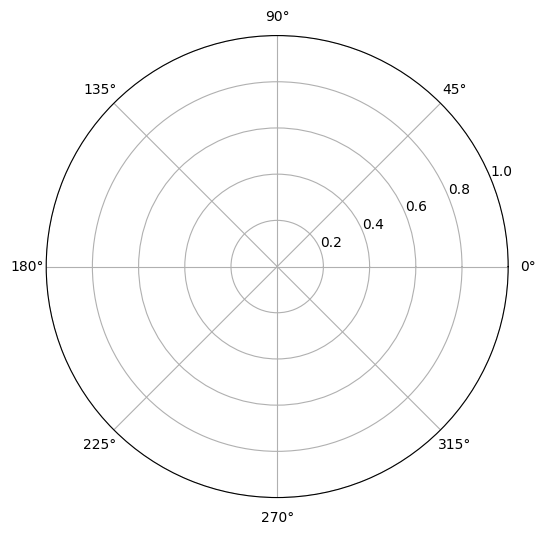

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Choose a character to visualize
char = 'ChatGPT'  # Replace with a specific character name
char_data = character_profiles.loc[char]

# Extract topics and sentiment proportions
topics = char_data.filter(like='Topic').values
sentiments = char_data.filter(items=['POSITIVE', 'NEUTRAL', 'NEGATIVE']).values

# Prepare for radar chart
labels = list(character_topic_means.columns) + ['POSITIVE', 'NEUTRAL', 'NEGATIVE']
values = np.concatenate([topics, sentiments])
values = np.append(values, values[0])  # Close the radar chart

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False)
angles = np.append(angles, angles[0])

# Plot radar chart
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.fill(angles, values, color='blue', alpha=0.25)
ax.plot(angles, values, color='blue', linewidth=2)
ax.set_yticks([])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10)

plt.title(f"Profile of {char}")
plt.show()


ValueError: x and y must have same first dimension, but have shapes (33,) and (8,)

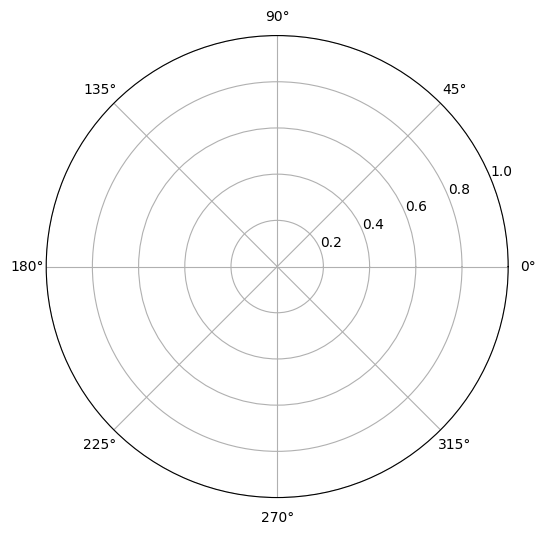

In [17]:
# Prepare for radar chart
labels = list(character_topic_means.columns) + ['POSITIVE', 'NEUTRAL', 'NEGATIVE']
values = np.concatenate([topics, sentiments])

# Ensure the values array is closed for the radar chart
values = np.append(values, values[0])

# Calculate angles for each axis
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False)
angles = np.append(angles, angles[0])

# Plot radar chart
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.fill(angles, values, color='blue', alpha=0.25)
ax.plot(angles, values, color='blue', linewidth=2)
ax.set_yticks([])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10)

plt.title(f"Profile of {char}")
plt.show()